imports packages and libraries

In [67]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Lasso,LassoCV,Ridge,ElasticNet,RidgeCV,ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score

Task 1: exploratory data analysis

   loading dataset

In [68]:
df=pd.read_csv('Pharma_Industry.csv')

In [69]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


checking missing values

In [70]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

finding duplicates

In [71]:
df.duplicated().sum()

np.int64(0)

statistical summary of dataset

In [72]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


feature distribution

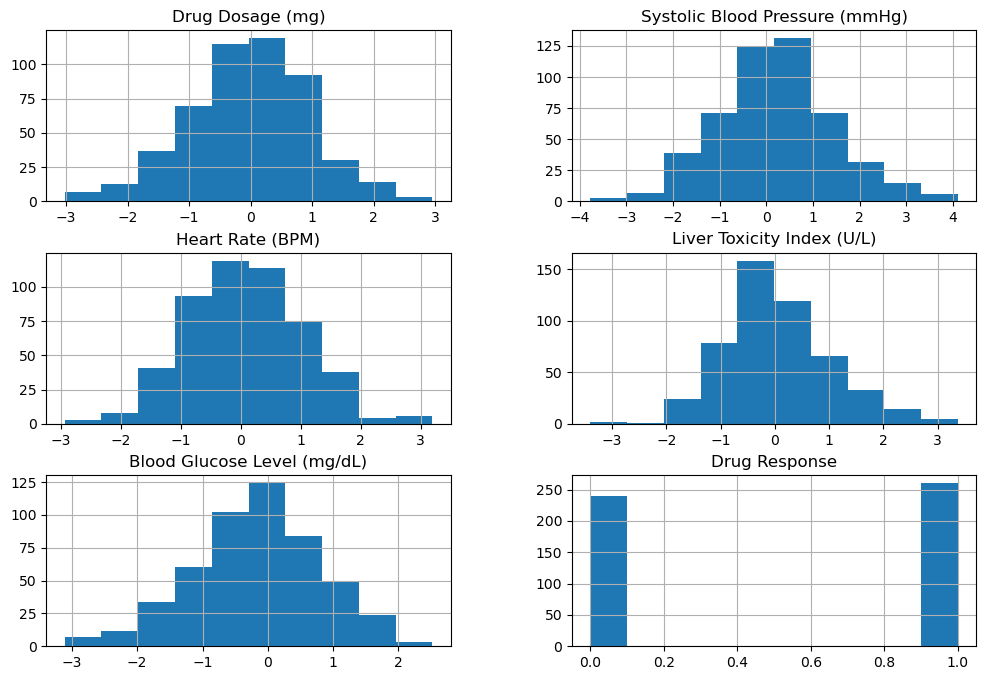

In [8]:
#### histogram 
df.hist(figsize=(12,8)) 
plt.show()

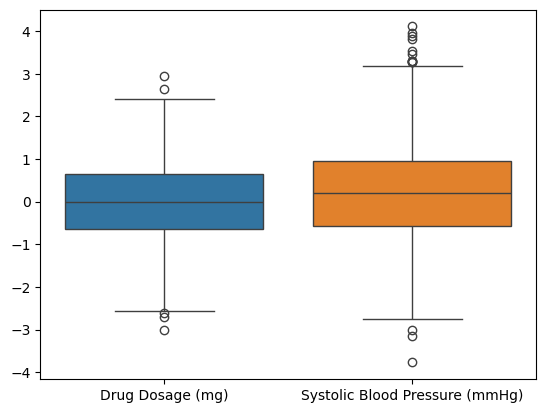

In [74]:
#### box plots
sns.boxplot(data=df[['Drug Dosage (mg)','Systolic Blood Pressure (mmHg)']])
plt.show()

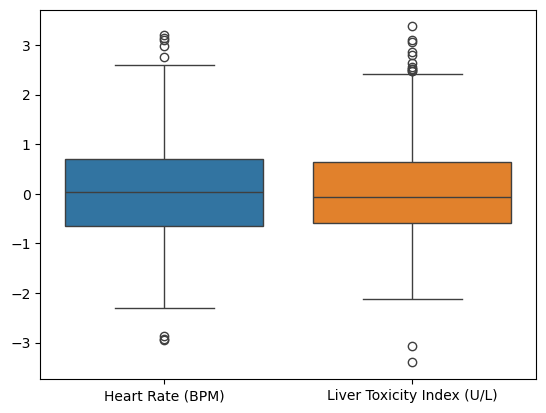

In [75]:
sns.boxplot(data=df[['Heart Rate (BPM)','Liver Toxicity Index (U/L)']])
plt.show()

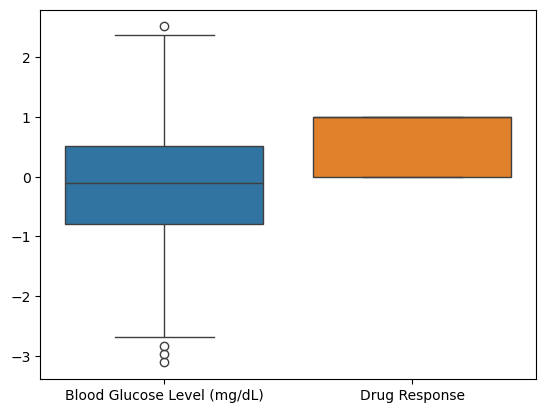

In [76]:
sns.boxplot(data=df[['Blood Glucose Level (mg/dL)','Drug Response']])
plt.show()

In [77]:
#### correlation between the features
corr=df.corr() 
corr

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


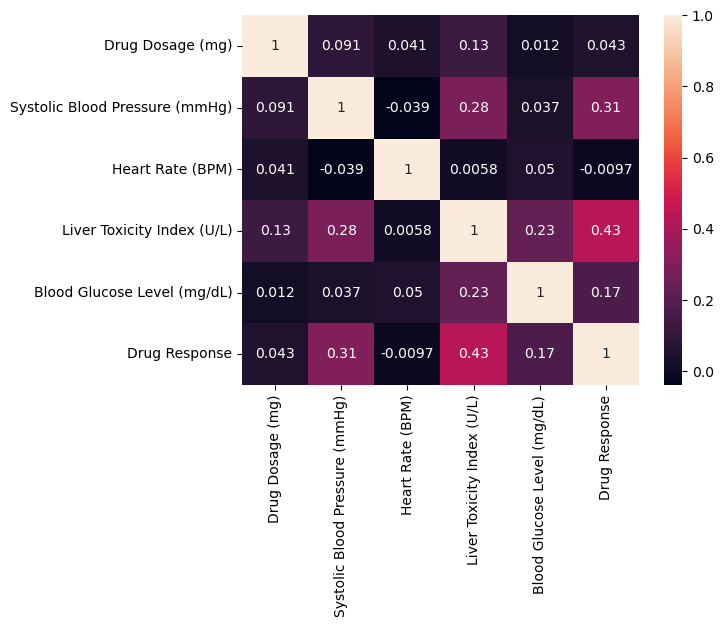

In [78]:
#### heatmap for correlation
sns.heatmap(corr,annot=True)
plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [17]:
### features selections
target=df[['Drug Response']] 
features=df.drop(columns=df[['Drug Response']])

Task 3 
  Data Visualization:
         ------ pairplot
         ------ class distribution 

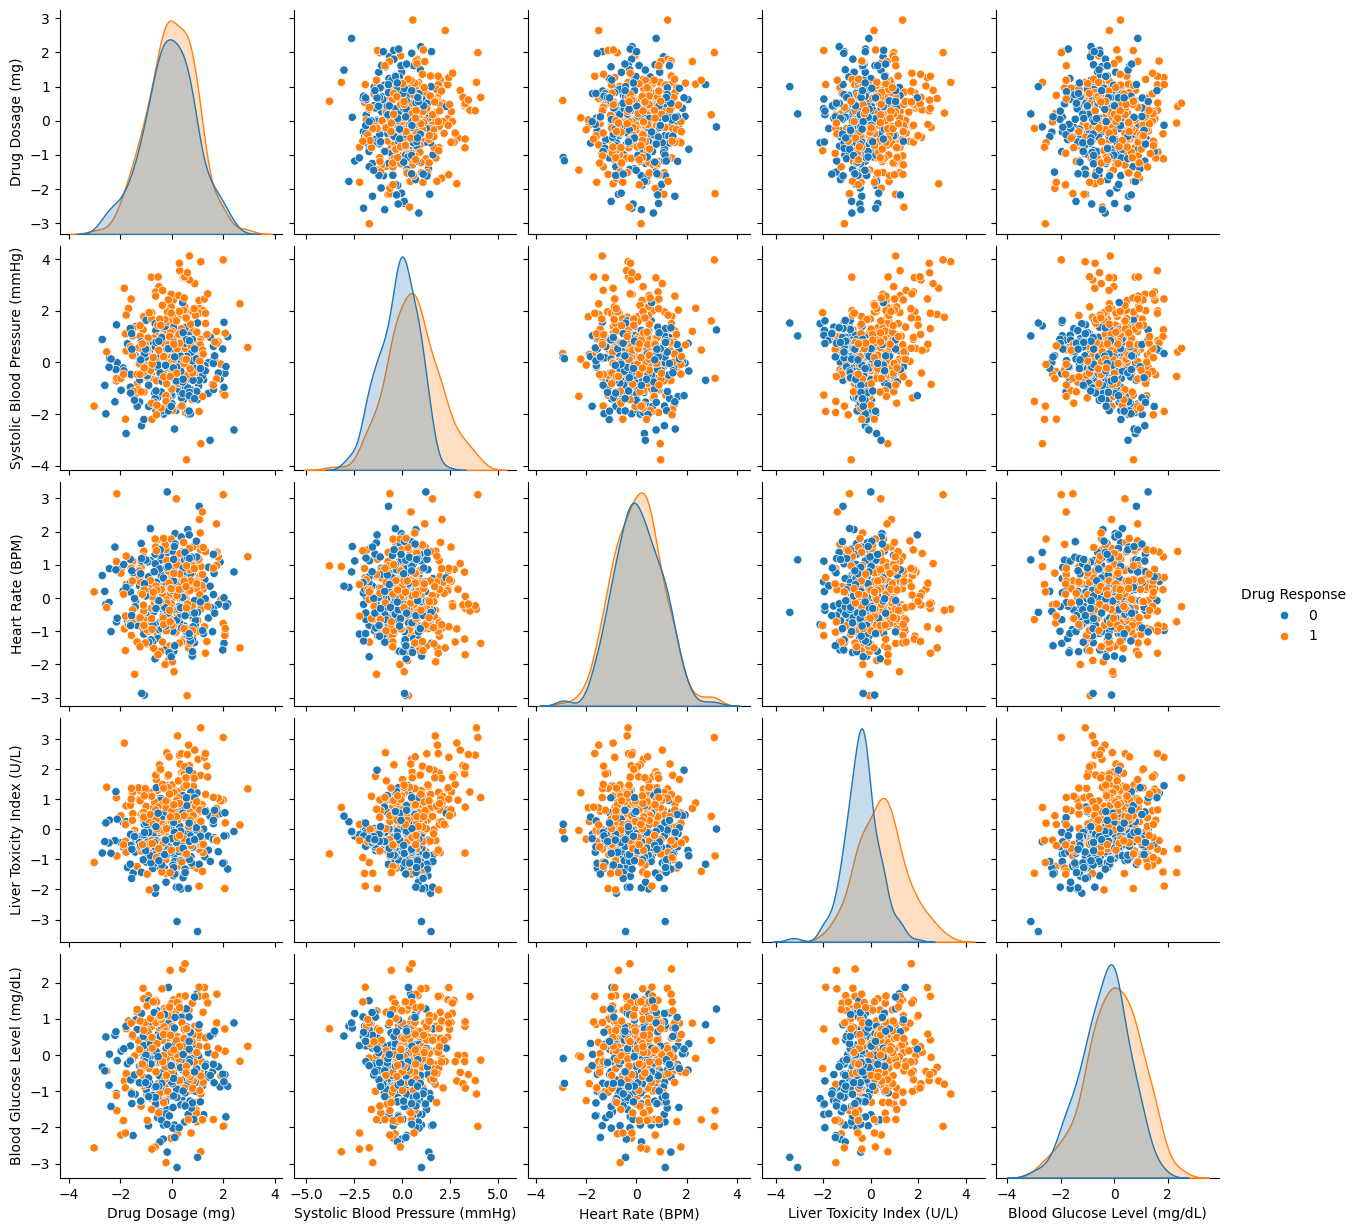

In [80]:
### pairplot
sns.pairplot(df,hue='Drug Response') 
plt.show()

class distribution

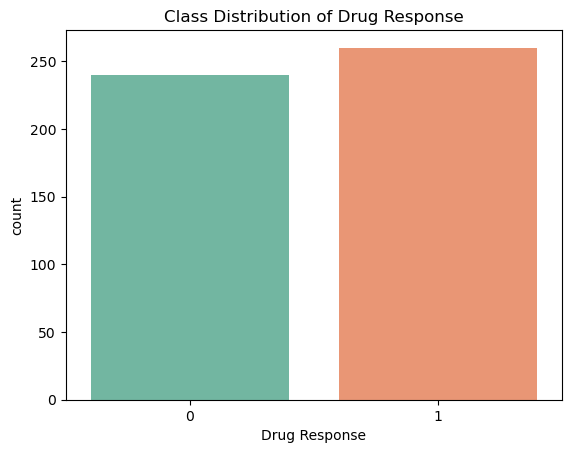

Drug Response
1    260
0    240
Name: count, dtype: int64


In [81]:
sns.countplot(x='Drug Response', data=df, palette='Set2')
plt.title("Class Distribution of Drug Response")
plt.show()

print(df['Drug Response'].value_counts())

In [18]:
target.head()

,Drug Response
0,1
1,1
2,0
3,1
4,1


In [19]:
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


In [20]:
#### data partition into training and test sets

In [21]:
x_train,x_test,y_train,y_test=train_test_split(features,target,
                                               train_size=0.8,random_state=100,stratify=df['Drug Response'])

In [22]:
print(x_train.shape) 
print(x_test.shape) 
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400, 1)
(100, 1)


In [23]:
### linear kernel
svc= SVC(C=1,kernel='linear')
svc.fit(x_train,y_train)
y_pred= svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.74

In [24]:
x_train.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
59,0.331980,0.292810,0.190500,0.105008,0.010960
54,0.871297,0.154579,-1.345980,-0.292493,-0.780908
82,2.062525,-0.426294,-1.067533,0.548899,-0.539461
244,-1.776235,0.438991,0.408653,0.777159,0.724584
335,-0.369277,2.201547,0.143388,0.169955,0.405176


In [32]:
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report

In [26]:
precision_score(y_test,y_pred)

0.76

In [27]:
recall_score(y_test,y_pred)

0.7307692307692307

In [28]:
f1_score(y_test,y_pred)

0.7450980392156863

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73        48
           1       0.76      0.73      0.75        52

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100



Task 3: Data visualization

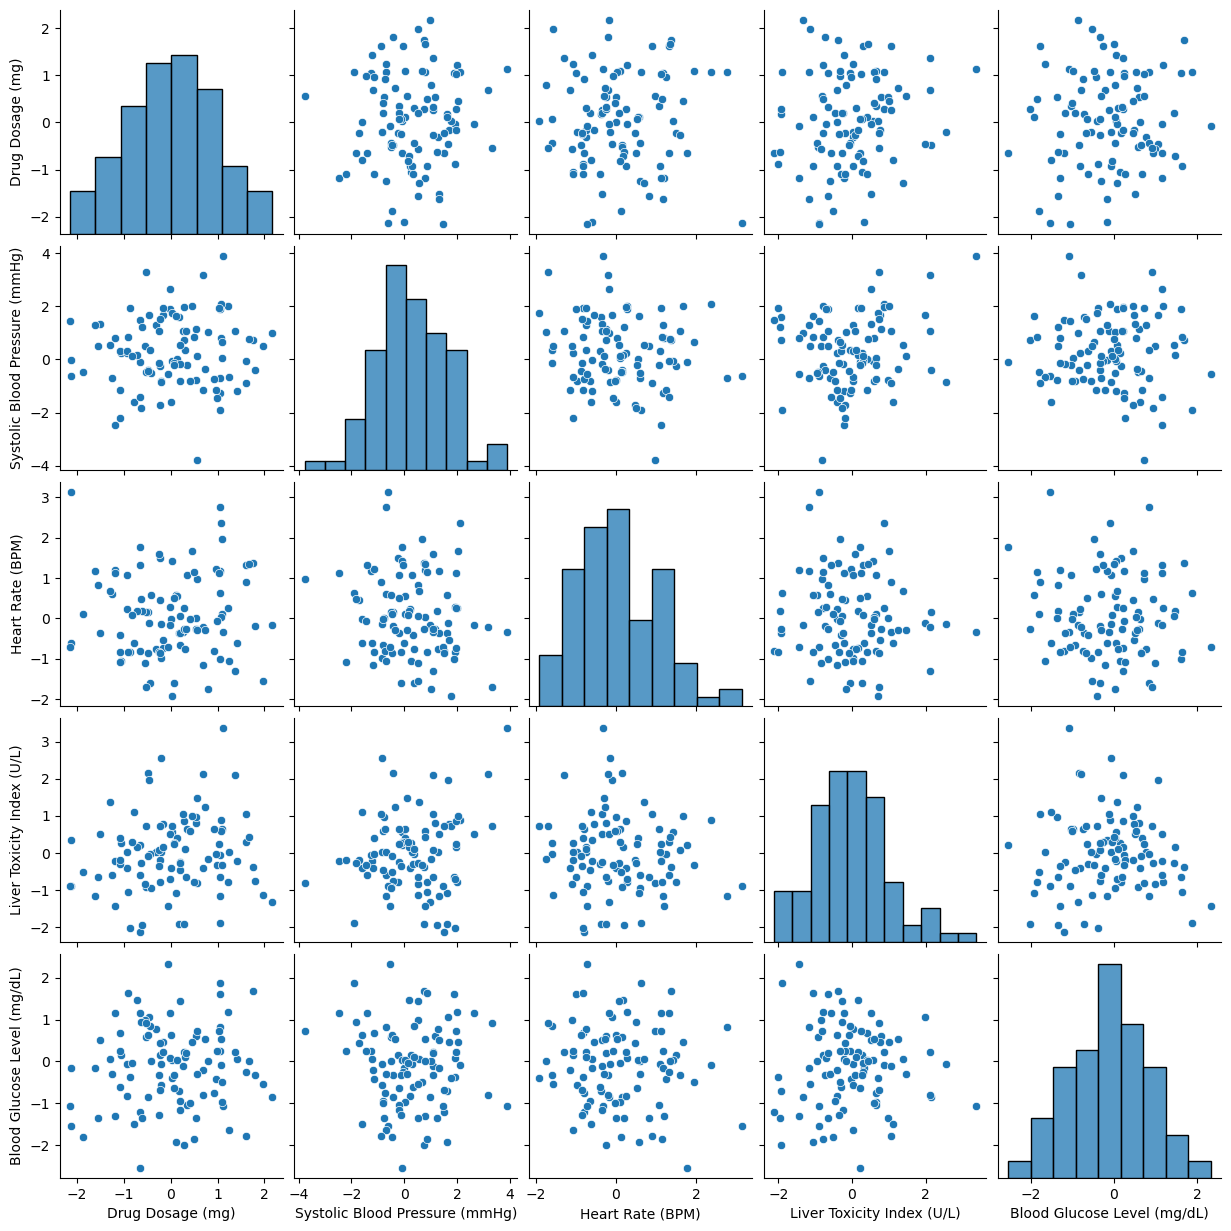

In [35]:
sns.pairplot(x_test) 
plt.show()

In [36]:
target.head()

,Drug Response
0,1
1,1
2,0
3,1
4,1


In [37]:
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0])

In [38]:
x_train.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
59,0.331980,0.292810,0.190500,0.105008,0.010960
54,0.871297,0.154579,-1.345980,-0.292493,-0.780908
82,2.062525,-0.426294,-1.067533,0.548899,-0.539461
244,-1.776235,0.438991,0.408653,0.777159,0.724584
335,-0.369277,2.201547,0.143388,0.169955,0.405176


In [46]:
h=0.02
np.arange(x_min,x_max,h),np.arange(y_min,y_max,h)

(array([-4.01951216e+00, -3.99951216e+00, -3.97951216e+00, -3.95951216e+00,
        -3.93951216e+00, -3.91951216e+00, -3.89951216e+00, -3.87951216e+00,
        -3.85951216e+00, -3.83951216e+00, -3.81951216e+00, -3.79951216e+00,
        -3.77951216e+00, -3.75951216e+00, -3.73951216e+00, -3.71951216e+00,
        -3.69951216e+00, -3.67951216e+00, -3.65951216e+00, -3.63951216e+00,
        -3.61951216e+00, -3.59951216e+00, -3.57951216e+00, -3.55951216e+00,
        -3.53951216e+00, -3.51951216e+00, -3.49951216e+00, -3.47951216e+00,
        -3.45951216e+00, -3.43951216e+00, -3.41951216e+00, -3.39951216e+00,
        -3.37951216e+00, -3.35951216e+00, -3.33951216e+00, -3.31951216e+00,
        -3.29951216e+00, -3.27951216e+00, -3.25951216e+00, -3.23951216e+00,
        -3.21951216e+00, -3.19951216e+00, -3.17951216e+00, -3.15951216e+00,
        -3.13951216e+00, -3.11951216e+00, -3.09951216e+00, -3.07951216e+00,
        -3.05951216e+00, -3.03951216e+00, -3.01951216e+00, -2.99951216e+00,
        -2.9

In [47]:
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

In [48]:
np.ravel(xx),np.ravel(yy)

(array([-4.01951216, -3.99951216, -3.97951216, ...,  3.90048784,
         3.92048784,  3.94048784], shape=(197505,)),
 array([-4.77389654, -4.77389654, -4.77389654, ...,  5.10610346,
         5.10610346,  5.10610346], shape=(197505,)))

In [39]:
data=np.c_[np.ravel(xx),np.ravel(yy)]
data

array([[-4.01951216, -4.77389654],
       [-3.99951216, -4.77389654],
       [-3.97951216, -4.77389654],
       ...,
       [ 3.90048784,  5.10610346],
       [ 3.92048784,  5.10610346],
       [ 3.94048784,  5.10610346]], shape=(197505, 2))

In [42]:
clf=SVC(kernel='rbf',C=1,gamma='scale') 
clf.fit(x_train,y_train) 
y_pred=clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.79

In [43]:
x_two=df.iloc[:,[0,1]]
y=target

In [44]:
clf.fit(x_two,y)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [45]:
x_min, x_max = x_two.iloc[:, 0].min() - 1, x_two.iloc[:, 0].max() + 1
y_min, y_max = x_two.iloc[:, 1].min() - 1, x_two.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

In [64]:
### sigmoid
### kernel
svc=SVC(C=1,kernel='sigmoid',gamma=0.01,coef0=1) 
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.77

In [65]:
x_min, x_max = x_two.iloc[:, 0].min() - 1, x_two.iloc[:, 0].max() + 1
y_min, y_max = x_two.iloc[:, 1].min() - 1, x_two.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

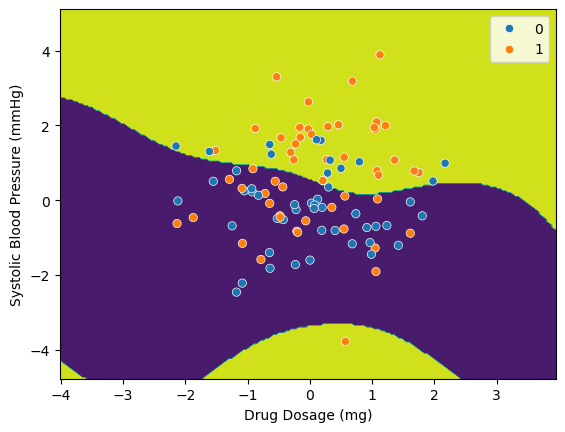

In [66]:
plt.contourf(xx,yy,Z)
sns.scatterplot(x=x_test.iloc[:,0],y=x_test.iloc[:,1],  hue=y_test.values.ravel())
plt.show()

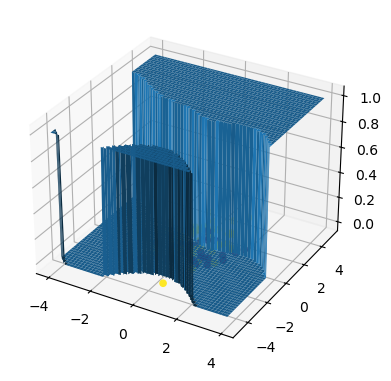

In [119]:
#### 3-D plot 
fig= plt.figure(figsize=(10,10))
ax= fig.add_subplot(222,projection='3d')
ax.plot_surface(xx,yy,Z)
ax.scatter(x_test.iloc[:,0],x_test.iloc[:,1],  c=y_test.values.ravel())
plt.show()